# PINN a posteriori estimator on the unit square

This notebook trains a PINN for the manufactured Poisson problem on $\Omega=[0,1]^2$, and computes certified interval enclosures for:

- the interior residual norm $\|r_\theta\|_{L^2(\Omega)}$ using **interval Hessian bounds**,
- the boundary mismatch norm $\|u_\theta-g\|_{L^2(\partial\Omega)}$,
- and the combined estimator $\eta_\theta$.

## 1) Setup and imports

In [3]:
from __future__ import annotations

import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
from pathlib import Path as _Path
from IPython.display import Image, display
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

repo_root = Path.cwd()
while not (repo_root / "src" / "intervalnets").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
if str(repo_root / "src") not in __import__('sys').path:
    __import__('sys').path.insert(0, str(repo_root / "src"))

from intervalnets import Interval, IntervalTensor, enable_interval_eval

enable_interval_eval(enclosure_mode="slope")

dtype = torch.float64
device = torch.device("cpu")
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"torch={torch.__version__}, dtype={dtype}, seed={SEED}")


PLOT_OUTPUT_DIR = _Path("notebooks") / "artifacts"
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
def finalize_figure(fig, filename: str, show_inline: bool = True):
    out_path = PLOT_OUTPUT_DIR / filename
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    print(f"saved figure: {out_path}")
    if show_inline:
        display(Image(filename=str(out_path)))
    plt.close(fig)

torch=2.0.0+cu117, dtype=torch.float64, seed=1234


## 2) Problem definition (PDE, localized forcing, BC)


In [5]:
PI = math.pi

# Two strongly localized Gaussian bumps for the RHS forcing term.
LOCAL_BUMPS = [
    # (x_center, y_center, sigma, amplitude)
    (0.28, 0.72, 0.055, 95.0),
    (0.74, 0.31, 0.045, -80.0),
]


def forcing_f(xy: torch.Tensor) -> torch.Tensor:
    x = xy[:, 0:1]
    y = xy[:, 1:2]
    f = torch.zeros_like(x)
    for cx, cy, sigma, amp in LOCAL_BUMPS:
        r2 = (x - cx) ** 2 + (y - cy) ** 2
        f = f + amp * torch.exp(-r2 / (2.0 * sigma ** 2))
    return f


def forcing_interval_on_box(box: IntervalTensor) -> Interval:
    x_lo, y_lo = float(box.lower[0]), float(box.lower[1])
    x_hi, y_hi = float(box.upper[0]), float(box.upper[1])

    f_lo = 0.0
    f_hi = 0.0

    for cx, cy, sigma, amp in LOCAL_BUMPS:
        # Squared-distance range from a box to bump center.
        if x_lo <= cx <= x_hi:
            dx_min = 0.0
        else:
            dx_min = min(abs(x_lo - cx), abs(x_hi - cx))
        if y_lo <= cy <= y_hi:
            dy_min = 0.0
        else:
            dy_min = min(abs(y_lo - cy), abs(y_hi - cy))
        r2_min = dx_min ** 2 + dy_min ** 2

        dx_max = max(abs(x_lo - cx), abs(x_hi - cx))
        dy_max = max(abs(y_lo - cy), abs(y_hi - cy))
        r2_max = dx_max ** 2 + dy_max ** 2

        gauss_min = math.exp(-r2_max / (2.0 * sigma ** 2))
        gauss_max = math.exp(-r2_min / (2.0 * sigma ** 2))

        if amp >= 0.0:
            term_lo = amp * gauss_min
            term_hi = amp * gauss_max
        else:
            term_lo = amp * gauss_max
            term_hi = amp * gauss_min

        f_lo += term_lo
        f_hi += term_hi

    return Interval.from_bounds(f_lo, f_hi)


def g_boundary(xy: torch.Tensor) -> torch.Tensor:
    return torch.zeros((xy.shape[0], 1), dtype=xy.dtype, device=xy.device)



## 3) PINN model

In [7]:
def make_pinn(width: int = 64, hidden_layers: int = 4) -> nn.Sequential:
    layers: list[nn.Module] = [nn.Linear(2, width), nn.Tanh()]
    for _ in range(hidden_layers - 1):
        layers += [nn.Linear(width, width), nn.Tanh()]
    layers += [nn.Linear(width, 1)]
    return nn.Sequential(*layers)

model = make_pinn(width=64, hidden_layers=2).to(device=device, dtype=dtype)
model

Sequential(
  (0): Linear(in_features=2, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=1, bias=True)
)

## 4) Training data sampling (interior + boundary)

In [9]:
def sample_interior(n: int) -> torch.Tensor:
    return torch.rand((n, 2), dtype=dtype, device=device)


def sample_boundary(n_per_edge: int) -> torch.Tensor:
    t = torch.rand((n_per_edge, 1), dtype=dtype, device=device)
    z = torch.zeros_like(t)
    o = torch.ones_like(t)
    return torch.cat([
        torch.cat([t, z], dim=1),
        torch.cat([t, o], dim=1),
        torch.cat([z, t], dim=1),
        torch.cat([o, t], dim=1),
    ], dim=0)


def laplacian_u_autograd(model: nn.Module, xy: torch.Tensor, create_graph: bool = True) -> torch.Tensor:
    # We always need first-derivative graph construction to differentiate once more.
    # The create_graph flag controls whether we keep graph info beyond second derivatives.
    with torch.enable_grad():
        xy_req = xy.detach().clone().requires_grad_(True)
        u = model(xy_req)
        grad_u = torch.autograd.grad(u, xy_req, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(
            grad_u[:, 0:1],
            xy_req,
            grad_outputs=torch.ones_like(grad_u[:, 0:1]),
            retain_graph=True,
            create_graph=create_graph,
        )[0][:, 0:1]
        u_yy = torch.autograd.grad(
            grad_u[:, 1:2],
            xy_req,
            grad_outputs=torch.ones_like(grad_u[:, 1:2]),
            create_graph=create_graph,
        )[0][:, 1:2]
    return u_xx + u_yy


def residual_r(model: nn.Module, xy: torch.Tensor, create_graph: bool = True) -> torch.Tensor:
    return -laplacian_u_autograd(model, xy, create_graph=create_graph) - forcing_f(xy)


## 5) Training loop

In [11]:
EPOCHS = 2000
LR = 1e-3
W_INTERIOR = 1.0
W_BOUNDARY = 20.0
N_INTERIOR = 1024
N_BDRY_PER_EDGE = 256
WEIGHT_DECAY = 1e-5

opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
history = {"total": [], "interior": [], "boundary": []}

for epoch in range(1, EPOCHS + 1):
    xi = sample_interior(N_INTERIOR)
    xb = sample_boundary(N_BDRY_PER_EDGE)

    ri = residual_r(model, xi)
    bm = model(xb) - g_boundary(xb)

    li = torch.mean(ri ** 2)
    lb = torch.mean(bm ** 2)
    loss = W_INTERIOR * li + W_BOUNDARY * lb

    opt.zero_grad()
    loss.backward()
    opt.step()

    history["total"].append(float(loss.detach().cpu()))
    history["interior"].append(float(li.detach().cpu()))
    history["boundary"].append(float(lb.detach().cpu()))

    if epoch % 200 == 0:
        print(f"epoch={epoch:4d} total={history['total'][-1]:.3e} interior={history['interior'][-1]:.3e} boundary={history['boundary'][-1]:.3e}")



epoch= 200 total=5.317e+01 interior=5.307e+01 boundary=4.861e-03
epoch= 400 total=2.171e+01 interior=2.161e+01 boundary=5.158e-03
epoch= 600 total=1.002e+01 interior=9.944e+00 boundary=3.642e-03
epoch= 800 total=6.141e+00 interior=6.042e+00 boundary=4.927e-03
epoch=1000 total=3.956e+00 interior=3.866e+00 boundary=4.492e-03
epoch=1200 total=4.350e+00 interior=4.279e+00 boundary=3.555e-03
epoch=1400 total=2.896e+00 interior=2.865e+00 boundary=1.561e-03
epoch=1600 total=2.322e+00 interior=2.288e+00 boundary=1.712e-03
epoch=1800 total=2.002e+00 interior=1.969e+00 boundary=1.656e-03
epoch=2000 total=1.669e+00 interior=1.635e+00 boundary=1.708e-03


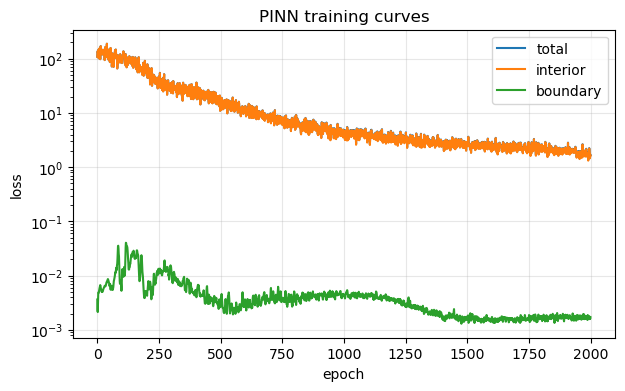

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.semilogy(history["total"], label="total")
ax.semilogy(history["interior"], label="interior")
ax.semilogy(history["boundary"], label="boundary")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("PINN training curves")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 6) Sanity diagnostics (sampled residual and boundary mismatch)

In [14]:
@torch.no_grad()
def sample_l2_norm(values: torch.Tensor) -> float:
    return float(torch.sqrt(torch.mean(values**2)).cpu())

xi_diag = sample_interior(20000)
xb_diag = sample_boundary(2000)

r_diag = residual_r(model, xi_diag).detach()
b_diag = (model(xb_diag) - g_boundary(xb_diag)).detach()
f_diag = forcing_f(xi_diag).detach()

empirical = {
    "||r_theta||_{L2(Ω), MC}": sample_l2_norm(r_diag),
    "||u_theta-g||_{L2(∂Ω), MC}": sample_l2_norm(b_diag),
    "||f||_{L2(Ω), MC}": sample_l2_norm(f_diag),
    "||f||_{L∞(Ω), MC}": float(torch.max(torch.abs(f_diag)).cpu()),
}
for k, v in empirical.items():
    print(f"{k:35s}: {v:.6e}")



||r_theta||_{L2(Ω), MC}            : 1.292829e+00
||u_theta-g||_{L2(∂Ω), MC}         : 4.116012e-02
||f||_{L2(Ω), MC}                  : 1.083314e+01
||f||_{L∞(Ω), MC}                  : 9.451307e+01


## 7) Certified interval enclosure of residual $L^2(\Omega)$ (direct Hessian-based)

In [16]:
def interval_abs(iv: Interval) -> Interval:
    lo = float(iv.lower)
    hi = float(iv.upper)
    if lo >= 0.0:
        return Interval.from_bounds(lo, hi)
    if hi <= 0.0:
        return Interval.from_bounds(-hi, -lo)
    return Interval.from_bounds(0.0, max(-lo, hi))


def residual_pointwise_power_bounds(model: nn.Module, box: IntervalTensor) -> Interval:
    hess = model.eval_hessian(box)
    u_xx = Interval(hess.lower[0][0][0], hess.upper[0][0][0])
    u_yy = Interval(hess.lower[0][1][1], hess.upper[0][1][1])
    lap = u_xx + u_yy
    f_iv = forcing_interval_on_box(box)
    r_iv = (Interval.point(0.0) - lap) - f_iv
    abs_r = interval_abs(r_iv)
    return abs_r * abs_r


def split_box(box: IntervalTensor):
    widths = [float(box.upper[i] - box.lower[i]) for i in range(len(box.lower))]
    dim = int(np.argmax(widths))
    mid = 0.5 * (float(box.lower[dim]) + float(box.upper[dim]))
    lo1 = list(box.lower)
    up1 = list(box.upper)
    lo2 = list(box.lower)
    up2 = list(box.upper)
    up1[dim] = mid
    lo2[dim] = mid
    return IntervalTensor.from_bounds(lo1, up1), IntervalTensor.from_bounds(lo2, up2)


def box_volume(box: IntervalTensor) -> float:
    vol = 1.0
    for lo, hi in zip(box.lower, box.upper):
        vol *= float(hi - lo)
    return vol


def certified_residual_l2(model: nn.Module, domain: IntervalTensor, iterations: int = 6, theta: float = 0.6, return_boxes: bool = False):
    def box_key(box: IntervalTensor):
        return (
            tuple(float(v) for v in box.lower),
            tuple(float(v) for v in box.upper),
        )

    power_cache = {}

    def cached_power_iv(box: IntervalTensor) -> Interval:
        key = box_key(box)
        if key not in power_cache:
            power_cache[key] = residual_pointwise_power_bounds(model, box)
        return power_cache[key]

    boxes = [domain]
    for _ in range(iterations):
        indicators = []
        for box in boxes:
            iv = cached_power_iv(box)
            indicators.append((float(iv.upper) - float(iv.lower)) * box_volume(box))
        total = sum(indicators)
        order = np.argsort(indicators)[::-1]
        marked = []
        running = 0.0
        target = theta * total
        for idx in order:
            marked.append(int(idx))
            running += indicators[int(idx)]
            if running >= target:
                break
        marked_set = set(marked)
        new_boxes = []
        for i, box in enumerate(boxes):
            if i in marked_set:
                a, b = split_box(box)
                new_boxes.extend([a, b])
            else:
                new_boxes.append(box)
        boxes = new_boxes

    integral = Interval.point(0.0)
    final_indicators = []
    for box in boxes:
        power_iv = cached_power_iv(box)
        vol = box_volume(box)
        weighted = Interval.from_bounds(float(power_iv.lower) * vol, float(power_iv.upper) * vol)
        integral = integral + weighted
        final_indicators.append((float(power_iv.upper) - float(power_iv.lower)) * vol)
    result = Interval.from_bounds(math.sqrt(max(0.0, float(integral.lower))), math.sqrt(max(0.0, float(integral.upper))))

    if return_boxes:
        return result, boxes, final_indicators
    return result

DOMAIN_2D = IntervalTensor.from_bounds([0.0, 0.0], [1.0, 1.0])
RES_ITERS = 24
RES_THETA = 0.5
residual_l2_iv, residual_boxes, residual_indicators = certified_residual_l2(model, DOMAIN_2D, iterations=RES_ITERS, theta=RES_THETA, return_boxes=True)
print(f"Certified ||r_theta||_L2(Ω) ∈ [{float(residual_l2_iv.lower):.6e}, {float(residual_l2_iv.upper):.6e}], width={float(residual_l2_iv.upper-residual_l2_iv.lower):.3e}")


Certified ||r_theta||_L2(Ω) ∈ [0.000000e+00, 6.576903e+01], width=6.577e+01


## 8) Certified interval enclosure of boundary trace $L^2(\partial\Omega)$

In [18]:
def make_edge_map(kind: str) -> nn.Linear:
    layer = nn.Linear(1, 2, bias=True).to(device=device, dtype=dtype)
    with torch.no_grad():
        if kind == "t0":
            layer.weight[:] = torch.tensor([[1.0], [0.0]], dtype=dtype)
            layer.bias[:] = torch.tensor([0.0, 0.0], dtype=dtype)
        elif kind == "t1":
            layer.weight[:] = torch.tensor([[1.0], [0.0]], dtype=dtype)
            layer.bias[:] = torch.tensor([0.0, 1.0], dtype=dtype)
        elif kind == "0t":
            layer.weight[:] = torch.tensor([[0.0], [1.0]], dtype=dtype)
            layer.bias[:] = torch.tensor([0.0, 0.0], dtype=dtype)
        elif kind == "1t":
            layer.weight[:] = torch.tensor([[0.0], [1.0]], dtype=dtype)
            layer.bias[:] = torch.tensor([1.0, 0.0], dtype=dtype)
        else:
            raise ValueError(kind)
    for p in layer.parameters():
        p.requires_grad_(False)
    return layer

edge_models = {
    "edge1:(t,0)": nn.Sequential(make_edge_map("t0"), model),
    "edge2:(t,1)": nn.Sequential(make_edge_map("t1"), model),
    "edge3:(0,t)": nn.Sequential(make_edge_map("0t"), model),
    "edge4:(1,t)": nn.Sequential(make_edge_map("1t"), model),
}

DOMAIN_1D = IntervalTensor.from_bounds([0.0], [1.0])
BND_ITERS = 24
BND_THETA = 0.5
BND_FORWARD_SPLITS = 3

edge_norm_intervals = {}
for name, edge_model in edge_models.items():
    iv = edge_model.lpnorm(DOMAIN_1D, p=2.0, iterations=BND_ITERS, theta=BND_THETA, forward_refine_splits=BND_FORWARD_SPLITS)
    edge_norm_intervals[name] = iv
    print(f"{name:14s}: [{float(iv.lower):.6e}, {float(iv.upper):.6e}] width={float(iv.upper-iv.lower):.3e}")

sum_lower = 0.0
sum_upper = 0.0
for iv in edge_norm_intervals.values():
    lk = max(0.0, float(iv.lower))
    uk = max(0.0, float(iv.upper))
    sum_lower += lk * lk
    sum_upper += uk * uk
boundary_l2_iv = Interval.from_bounds(math.sqrt(sum_lower), math.sqrt(sum_upper))
print(f"Global certified ||u_theta-g||_L2(∂Ω) ∈ [{float(boundary_l2_iv.lower):.6e}, {float(boundary_l2_iv.upper):.6e}]")

edge1:(t,0)   : [3.506029e-02, 3.660975e-02] width=1.549e-03
edge2:(t,1)   : [3.534749e-02, 3.685463e-02] width=1.507e-03
edge3:(0,t)   : [4.603990e-02, 4.803630e-02] width=1.996e-03
edge4:(1,t)   : [4.541635e-02, 4.722870e-02] width=1.812e-03
Global certified ||u_theta-g||_L2(∂Ω) ∈ [8.161487e-02, 8.506805e-02]


## 9) Combined a posteriori estimator

In [20]:
eta_iv = residual_l2_iv + boundary_l2_iv
print(f"η interval: [{float(eta_iv.lower):.6e}, {float(eta_iv.upper):.6e}], width={float(eta_iv.upper-eta_iv.lower):.3e}")

η interval: [8.161487e-02, 6.585410e+01], width=6.577e+01


## 10) PINN field visualizations

We visualize:
1. PINN solution $u_\theta$,
2. absolute error $|u_\theta-u^*|$,
3. local certified residual indicators used in adaptive refinement.

In [ ]:
# (a) solution and (b) PDE residual on a regular grid
N_PLOT = 121
x = torch.linspace(0.0, 1.0, N_PLOT, dtype=dtype, device=device)
y = torch.linspace(0.0, 1.0, N_PLOT, dtype=dtype, device=device)
X, Y = torch.meshgrid(x, y, indexing="ij")
XY = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

with torch.no_grad():
    U_pred = model(XY).reshape(N_PLOT, N_PLOT).cpu().numpy()

# Compute residual in chunks (no graph retention) to avoid very large autograd graphs in visualization.
RES_CHUNK = 2048
r_parts = []
for XY_chunk in XY.split(RES_CHUNK):
    r_parts.append(residual_r(model, XY_chunk, create_graph=False).detach())
R_grid = torch.cat(r_parts, dim=0).reshape(N_PLOT, N_PLOT).cpu().numpy()
R_abs_max = float(np.max(np.abs(R_grid)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)

im0 = axes[0].imshow(U_pred.T, origin="lower", extent=[0, 1, 0, 1], cmap="viridis", aspect="equal")
axes[0].set_title("(a) PINN solution $u_\theta$")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

res_norm = plt.Normalize(vmin=-R_abs_max, vmax=R_abs_max) if R_abs_max > 0 else plt.Normalize(vmin=-1.0, vmax=1.0)
im1 = axes[1].imshow(R_grid.T, origin="lower", extent=[0, 1, 0, 1], cmap="coolwarm", norm=res_norm, aspect="equal")
axes[1].set_title("(b) Signed residual $r_\theta=-\Delta u_\theta-f$")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

# (c) local certified residual indicators per adaptive cell
axes[2].set_title("(c) Local residual indicators (final adaptive partition)")
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1)
axes[2].set_aspect("equal")
axes[2].set_xlabel("x"); axes[2].set_ylabel("y")

ind = np.array(residual_indicators, dtype=float)
if ind.size == 0:
    ind = np.array([0.0])
ind_min = float(ind.min())
ind_max = float(ind.max())

for box, val in zip(residual_boxes, residual_indicators):
    x0, y0 = float(box.lower[0]), float(box.lower[1])
    x1, y1 = float(box.upper[0]), float(box.upper[1])
    if ind_max > ind_min:
        alpha = 0.15 + 0.85 * ((float(val) - ind_min) / (ind_max - ind_min))
    else:
        alpha = 0.4
    rect = plt.Rectangle((x0, y0), x1 - x0, y1 - y0, facecolor=(0.1, 0.2, 0.8, alpha), edgecolor="black", linewidth=0.3)
    axes[2].add_patch(rect)

sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(vmin=ind_min, vmax=ind_max if ind_max > ind_min else ind_min + 1.0))
sm.set_array([])
fig.colorbar(sm, ax=axes[2], fraction=0.046, label="indicator magnitude")
finalize_figure(fig, "figure_pinn_results.png")


print(f"Grid max |residual|: {R_abs_max:.6e}")
print(f"Adaptive cells in indicator map: {len(residual_boxes)}")



saved figure: notebooks\artifacts\figure_pinn_results.png


## 11) Summary table and conclusions

In [ ]:
rows = [
    {
        "metric": "Residual ||r_theta||_L2(Ω)",
        "empirical": empirical["||r_theta||_{L2(Ω), MC}"],
        "cert_lower": float(residual_l2_iv.lower),
        "cert_upper": float(residual_l2_iv.upper),
        "width": float(residual_l2_iv.upper - residual_l2_iv.lower),
    },
    {
        "metric": "Boundary ||u_theta-g||_L2(∂Ω)",
        "empirical": empirical["||u_theta-g||_{L2(∂Ω), MC}"],
        "cert_lower": float(boundary_l2_iv.lower),
        "cert_upper": float(boundary_l2_iv.upper),
        "width": float(boundary_l2_iv.upper - boundary_l2_iv.lower),
    },
    {
        "metric": "Combined η",
        "empirical": np.nan,
        "cert_lower": float(eta_iv.lower),
        "cert_upper": float(eta_iv.upper),
        "width": float(eta_iv.upper - eta_iv.lower),
    },
]
for name, iv in edge_norm_intervals.items():
    rows.append({"metric": f"Per-edge {name}", "empirical": np.nan, "cert_lower": float(iv.lower), "cert_upper": float(iv.upper), "width": float(iv.upper-iv.lower)})

pd.DataFrame(rows)

### Interpretation

- The residual enclosure is now computed directly from certified Hessian bounds and interval forcing bounds on each adaptive cell.
- The boundary term remains certified via edge-wise `lpnorm` computations.
- The practical estimator $\eta_\theta = \|r_\theta\|_{L^2(\Omega)} + \|u_\theta-g\|_{L^2(\partial\Omega)}$ is therefore fully interval-certified in this notebook.